# Consigna del desafio 3

- Realizar un modelo de lenguaje con tokenización por caracteres
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.

### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.

In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import requests
import torchinfo
import matplotlib.pyplot as plt


## Datos

In [153]:
url = "https://www.gutenberg.org/ebooks/2000.txt.utf-8"

response = requests.get(url)
text = ''

if response.status_code == 200:
    text = response.text

text = text.lower()

In [154]:
print(text[:100])

the project gutenberg ebook of don quijote
    
this ebook is for the use of anyone anywhere in t


In [155]:
first_chapter = text.find("capítulo primero")
text = text[first_chapter:]


In [156]:
print(text[:1000])

capítulo primero. que trata de la condición y ejercicio del famoso hidalgo
don quijote de la mancha

en un lugar de la mancha, de cuyo nombre no quiero acordarme, no ha mucho
tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua,
rocín flaco y galgo corredor. una olla de algo más vaca que carnero,
salpicón las más noches, duelos y quebrantos los sábados, lantejas los
viernes, algún palomino de añadidura los domingos, consumían las tres
partes de su hacienda. el resto della concluían sayo de velarte, calzas de
velludo para las fiestas, con sus pantuflos de lo mesmo, y los días de
entresemana se honraba con su vellorí de lo más fino. tenía en su casa una
ama que pasaba de los cuarenta, y una sobrina que no llegaba a los veinte,
y un mozo de campo y plaza, que así ensillaba el rocín como tomaba la
podadera. frisaba la edad de nuestro hidalgo con los cincuenta años; era de
complexión recia, seco de carnes, enjuto de rostro, gran madrugador y amigo
de la ca


## Elegir tamaño del contexto

In [157]:
max_context_size = 100

## Tokenizado

In [158]:
class CharacterTokenizer:

    def __init__(self, text):
        self.chars = sorted(list(set(text)))

        self.vocab_size = len(self.chars)

        self.char2idx = {ch: i for i, ch in enumerate(self.chars)}
        self.idx2char = {i: ch for i, ch in enumerate(self.chars)}

    def encode(self, text_to_code):
        return [self.char2idx[c] for c in text_to_code]
    
    def decode(self, idx_lst):
        return [self.idx2char[i] for i in idx_lst]

In [159]:
tokenizer = CharacterTokenizer(text)
tokenized_text = tokenizer.encode(text)

In [160]:
tokenized_text[:1000]

[31,
 29,
 44,
 62,
 48,
 49,
 40,
 43,
 2,
 44,
 46,
 37,
 41,
 33,
 46,
 43,
 13,
 2,
 45,
 49,
 33,
 2,
 48,
 46,
 29,
 48,
 29,
 2,
 32,
 33,
 2,
 40,
 29,
 2,
 31,
 43,
 42,
 32,
 37,
 31,
 37,
 65,
 42,
 2,
 53,
 2,
 33,
 38,
 33,
 46,
 31,
 37,
 31,
 37,
 43,
 2,
 32,
 33,
 40,
 2,
 34,
 29,
 41,
 43,
 47,
 43,
 2,
 36,
 37,
 32,
 29,
 40,
 35,
 43,
 1,
 0,
 32,
 43,
 42,
 2,
 45,
 49,
 37,
 38,
 43,
 48,
 33,
 2,
 32,
 33,
 2,
 40,
 29,
 2,
 41,
 29,
 42,
 31,
 36,
 29,
 1,
 0,
 1,
 0,
 33,
 42,
 2,
 49,
 42,
 2,
 40,
 49,
 35,
 29,
 46,
 2,
 32,
 33,
 2,
 40,
 29,
 2,
 41,
 29,
 42,
 31,
 36,
 29,
 11,
 2,
 32,
 33,
 2,
 31,
 49,
 53,
 43,
 2,
 42,
 43,
 41,
 30,
 46,
 33,
 2,
 42,
 43,
 2,
 45,
 49,
 37,
 33,
 46,
 43,
 2,
 29,
 31,
 43,
 46,
 32,
 29,
 46,
 41,
 33,
 11,
 2,
 42,
 43,
 2,
 36,
 29,
 2,
 41,
 49,
 31,
 36,
 43,
 1,
 0,
 48,
 37,
 33,
 41,
 44,
 43,
 2,
 45,
 49,
 33,
 2,
 50,
 37,
 50,
 62,
 29,
 2,
 49,
 42,
 2,
 36,
 37,
 32,
 29,
 40,
 35,
 43,
 2,
 32,
 3

## Estructuracion del dataset

In [161]:
p_val = 0.9

X = []
y = []

for i in range(len(tokenized_text) - max_context_size):
    X.append(tokenized_text[i : i + max_context_size - 1])
    y.append(tokenized_text[i + 1 : i + max_context_size])


In [162]:
X_train = X[:int(len(X) * p_val)]
y_train = y[:int(len(X) * p_val)]

In [163]:
X_val = X[int(len(X) * p_val):]
y_val = y[int(len(X) * p_val):]


In [164]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [165]:
class CharDataset(Dataset):
    def __init__(self, X, y):
        super().__init__()
        self.x = torch.tensor(X)
        self.y = torch.tensor(y, dtype = torch.long)

    def __len__(self):
        return self.x.shape[0]
    
    def __getitem__(self, index):
        return self.x[index], self.y[index]

In [166]:
batch_size = 128

In [167]:
train_dataset = CharDataset(X_train, y_train)
val_dataset = CharDataset(X_val, y_val)
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
val_dataloader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)


## Modelo RNN

In [168]:
class CharModelRnn(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.rnn_size = 5
        self.num_layers = 2
        self.hidden_size = 64
        self.embedding = nn.Embedding(num_embeddings = vocab_size, embedding_dim = self.rnn_size)
        self.rnn = nn.RNN(input_size = self.rnn_size, hidden_size = self.hidden_size, num_layers = self.num_layers, batch_first = True, dropout = 0.3)
        self.fc = nn.Linear(in_features = self.hidden_size, out_features = vocab_size)


    def forward(self, x, prev_state = None):
        if prev_state is None:
            batch_size = x.shape[0] #(batch, seq_size)
            prev_state = self.init_hidden(batch_size)
    
        x = self.embedding(x)
        rnn_output, _ = self.rnn(x)
        x = self.fc(rnn_output)
        return x
    
    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device) #h_0
               



## Modelo LSTM

In [169]:
class CharModelLSTM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.lstm_size = 5
        self.num_layers = 2
        self.hidden_size = 64
        self.embedding = nn.Embedding(num_embeddings = vocab_size, embedding_dim = self.lstm_size)
        self.rnn = nn.LSTM(input_size=self.lstm_size, hidden_size=self.hidden_size, batch_first=True,
                            num_layers=self.num_layers, dropout=0.3)
        self.fc = nn.Linear(in_features = self.hidden_size, out_features = vocab_size)

    def forward(self, x, prev_state = None):
        if prev_state is None:
            batch_size = x.shape[0] #(batch, seq_size)
            prev_state = self.init_hidden(batch_size)
    
        x = self.embedding(x)
        rnn_output, (_, _)= self.rnn(x)
        x = self.fc(rnn_output)


        return x
    
    def init_hidden(self, batch_size):
        return (torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device),
                torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)) #h_0 y c_0
               



## Modelo GRU

In [170]:
class CharModelGRU(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.gru_size = 5
        self.num_layers = 2
        self.hidden_size = 64
        self.embedding = nn.Embedding(num_embeddings = vocab_size, embedding_dim = self.gru_size)
        self.rnn = nn.GRU(input_size=self.gru_size, hidden_size=self.hidden_size, batch_first=True,
                            num_layers=self.num_layers, dropout=0.3)
        self.fc = nn.Linear(in_features = self.hidden_size, out_features = vocab_size)

    def forward(self, x, prev_state = None):
        if prev_state is None:
            batch_size = x.shape[0] #(batch, seq_size)
            prev_state = self.init_hidden(batch_size)
    
        x = self.embedding(x)
        rnn_output, _ = self.rnn(x)
        x = self.fc(rnn_output)

        return x
    
    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)#h_0

In [171]:
rnn_model = CharModelRnn(vocab_size = tokenizer.vocab_size)
lstm_model = CharModelLSTM(vocab_size = tokenizer.vocab_size)
gru_model = CharModelGRU(vocab_size = tokenizer.vocab_size)


In [172]:
torchinfo.summary(rnn_model, input_size = (batch_size, max_context_size), dtypes=[torch.long])


Layer (type:depth-idx)                   Output Shape              Param #
CharModelRnn                             [128, 100, 76]            --
├─Embedding: 1-1                         [128, 100, 5]             380
├─RNN: 1-2                               [128, 100, 64]            12,864
├─Linear: 1-3                            [128, 100, 76]            4,940
Total params: 18,184
Trainable params: 18,184
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 165.34
Input size (MB): 0.10
Forward/backward pass size (MB): 14.85
Params size (MB): 0.07
Estimated Total Size (MB): 15.02

In [173]:
torchinfo.summary(lstm_model, input_size = (batch_size, max_context_size), dtypes=[torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
CharModelLSTM                            [128, 100, 76]            --
├─Embedding: 1-1                         [128, 100, 5]             380
├─LSTM: 1-2                              [128, 100, 64]            51,456
├─Linear: 1-3                            [128, 100, 76]            4,940
Total params: 56,776
Trainable params: 56,776
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 659.32
Input size (MB): 0.10
Forward/backward pass size (MB): 14.85
Params size (MB): 0.23
Estimated Total Size (MB): 15.18

In [174]:
torchinfo.summary(gru_model, input_size = (batch_size, max_context_size), dtypes=[torch.long])


Layer (type:depth-idx)                   Output Shape              Param #
CharModelGRU                             [128, 100, 76]            --
├─Embedding: 1-1                         [128, 100, 5]             380
├─GRU: 1-2                               [128, 100, 64]            38,592
├─Linear: 1-3                            [128, 100, 76]            4,940
Total params: 43,912
Trainable params: 43,912
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 494.66
Input size (MB): 0.10
Forward/backward pass size (MB): 14.85
Params size (MB): 0.18
Estimated Total Size (MB): 15.13

## Entrenamiento

In [175]:
from torchmetrics.classification import Accuracy

def train(model, train_loader, valid_loader, epochs, loss_function, optimizer, model_name):
    train_loss = []
    train_accuracy = []
    valid_loss = []
    valid_accuracy = []
    perplexity = []
    patience  = 3
    min_score = np.inf
    patience_conter = 0

    accuracy_metric = Accuracy(task="multiclass", num_classes=tokenizer.vocab_size).to(device)

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        accuracy_metric.reset()

        for train_data, train_target in train_loader:
            train_data = train_data.to(device)
            train_target = train_target.to(device)
            optimizer.zero_grad()

            epoch_y_hat = model(train_data)
            predictions_reshaped = epoch_y_hat.view(-1, tokenizer.vocab_size)
            targets_reshaped = train_target.view(-1)


            loss = loss_function(predictions_reshaped, targets_reshaped)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() 
            accuracy_metric.update(predictions_reshaped, targets_reshaped)

        epoch_train_loss = total_train_loss / len(train_loader)
        epoch_train_accuracy = accuracy_metric.compute()
        train_loss.append(epoch_train_loss)
        train_accuracy.append(epoch_train_accuracy.cpu().numpy())

        model.eval()
        total_valid_loss = 0
        accuracy_metric.reset() 

        with torch.no_grad(): # Desactiva el cálculo de gradientes
            for valid_data, valid_target in valid_loader:
                valid_data = valid_data.to(device)
                valid_target = valid_target.to(device)
                
                epoch_y_hat = model(valid_data)

                predictions_reshaped = epoch_y_hat.view(-1, tokenizer.vocab_size)
                targets_reshaped = valid_target.view(-1)

                loss = loss_function(predictions_reshaped, targets_reshaped)
                total_valid_loss += loss.item()
                accuracy_metric.update(predictions_reshaped, targets_reshaped)

        # 5. Calcular métricas finales de la época
        epoch_valid_loss = total_valid_loss / len(valid_loader)
        epoch_valid_accuracy = accuracy_metric.compute()
        valid_loss.append(epoch_valid_loss)
        valid_accuracy.append(epoch_valid_accuracy.cpu().numpy())
        
        epoch_perplexity = torch.exp(torch.tensor(epoch_valid_loss))
        perplexity.append(epoch_perplexity.item())

        print(f" Epoca: {epoch} | " \
          f"Train/Valid loss: {train_loss[-1]}/{valid_loss[-1]}) | " \
          f"Train/Valid acc: {train_accuracy[-1]}/{valid_accuracy[-1]}) | " \
          f"Perpelexity: {perplexity[-1]}")
    

        if perplexity[-1] < min_score:
            min_score = perplexity[-1]
            patience_conter = 0
            torch.save(model.state_dict(), model_name)
            print("Saved new model!")
        else: 
            patience_conter += 1
        if patience_conter == patience:
            break

        
    return {
        'train_loss': train_loss,
        'train_accuracy': train_accuracy,
        'valid_loss': valid_loss,
        'valid_accuracy': valid_accuracy,
        'perplexity': perplexity
    }

In [176]:
def ploter(loss, valid, title): 
    fig, ax = plt.subplots()
    ax.plot(range(len(loss)), loss, label = "train")
    ax.plot(range(len(loss)), valid, label = "valid")
    ax.set_title(title)
    ax.legend(fontsize=14)
    plt.show()

In [177]:
loss_function = nn.CrossEntropyLoss()
optimezer = torch.optim.RMSprop(params = rnn_model.parameters(), lr = 0.001)
rnn_model = rnn_model.to(device)
rnn_model_name = 'rnn_model.pth'
train_rnn_result = train(
    model = rnn_model,
    train_loader = train_dataloader,
    valid_loader = val_dataloader,
    epochs = 25,
    loss_function = loss_function,
    optimizer = optimezer,
    model_name = rnn_model_name
)


 Epoca: 0 | Train/Valid loss: 1.764465397434167/1.9313215409662177) | Train/Valid acc: 0.4550110399723053/0.45259445905685425) | Perpelexity: 6.89862060546875
Saved new model!
 Epoca: 1 | Train/Valid loss: 1.6684417085484355/1.9085806185731533) | Train/Valid acc: 0.4814307689666748/0.4610143303871155) | Perpelexity: 6.743510723114014
Saved new model!
 Epoca: 2 | Train/Valid loss: 1.6504000846719713/1.907079433204178) | Train/Valid acc: 0.4865629971027374/0.4613651633262634) | Perpelexity: 6.733395099639893
Saved new model!
 Epoca: 3 | Train/Valid loss: 1.6419361963416832/1.9106783196957677) | Train/Valid acc: 0.4892486035823822/0.4638268053531647) | Perpelexity: 6.757670879364014
 Epoca: 4 | Train/Valid loss: 1.6363087934056746/1.9071215065521168) | Train/Valid acc: 0.49087923765182495/0.46640652418136597) | Perpelexity: 6.733678340911865
 Epoca: 5 | Train/Valid loss: 1.6324099120732225/1.9102450900416368) | Train/Valid acc: 0.4918278455734253/0.4643274247646332) | Perpelexity: 6.75474

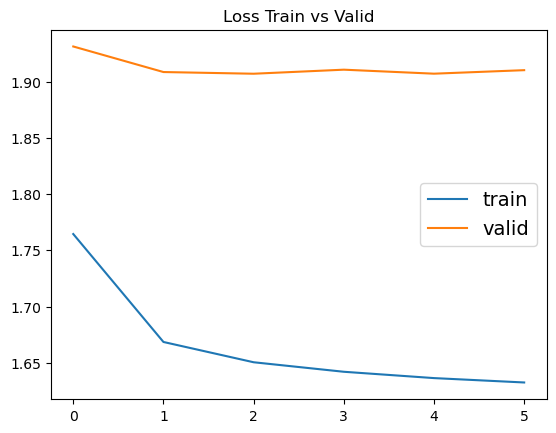

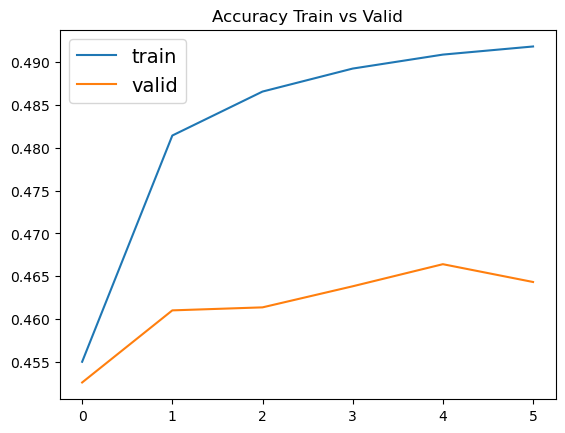

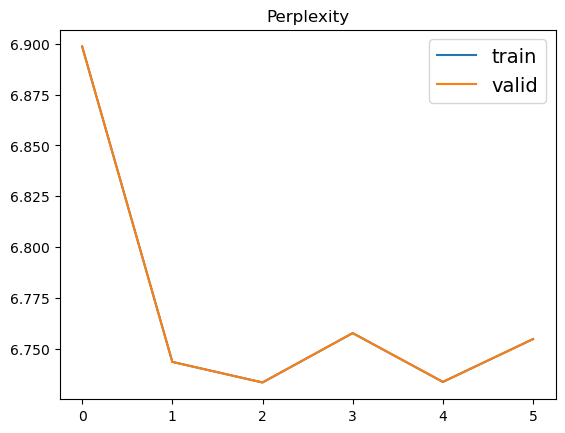

In [178]:
ploter(train_rnn_result['train_loss'], train_rnn_result['valid_loss'], "Loss Train vs Valid")
ploter(train_rnn_result['train_accuracy'], train_rnn_result['valid_accuracy'], "Accuracy Train vs Valid")
ploter(train_rnn_result['perplexity'], train_rnn_result['perplexity'], "Perplexity")


In [179]:
optimezer = torch.optim.RMSprop(params = lstm_model.parameters(), lr = 0.0001)
lstm_model_name = 'lstm_model.pth'

train_lstm_result = train(
    model = lstm_model,
    train_loader = train_dataloader,
    valid_loader = val_dataloader,
    epochs = 25,
    loss_function = loss_function,
    optimizer = optimezer,
    model_name = lstm_model_name
)


 Epoca: 0 | Train/Valid loss: 2.221137355744317/2.014200630027321) | Train/Valid acc: 0.3418290615081787/0.4170132577419281) | Perpelexity: 7.494734287261963
Saved new model!
 Epoca: 1 | Train/Valid loss: 1.7681294010070792/1.9066030763260007) | Train/Valid acc: 0.4548897445201874/0.4544251561164856) | Perpelexity: 6.730188369750977
Saved new model!
 Epoca: 2 | Train/Valid loss: 1.6776872306550068/1.8568070282718048) | Train/Valid acc: 0.4804680645465851/0.4738350212574005) | Perpelexity: 6.403258323669434
Saved new model!
 Epoca: 3 | Train/Valid loss: 1.6287640464124955/1.829570949579691) | Train/Valid acc: 0.4950333833694458/0.4849366843700409) | Perpelexity: 6.231213092803955
Saved new model!
 Epoca: 4 | Train/Valid loss: 1.5989217108772218/1.811708149496829) | Train/Valid acc: 0.503587543964386/0.490725040435791) | Perpelexity: 6.120893478393555
Saved new model!
 Epoca: 5 | Train/Valid loss: 1.5779424235329331/1.7998704624807218) | Train/Valid acc: 0.5095460414886475/0.495206087827

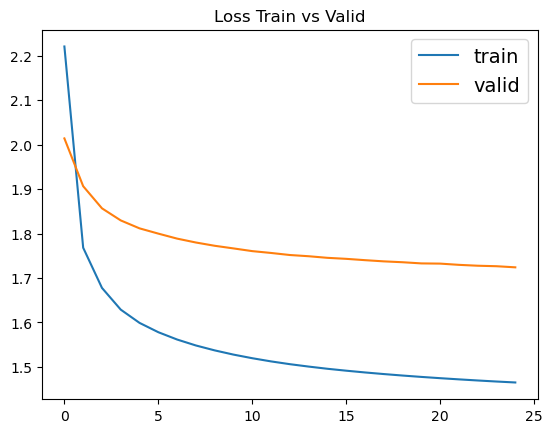

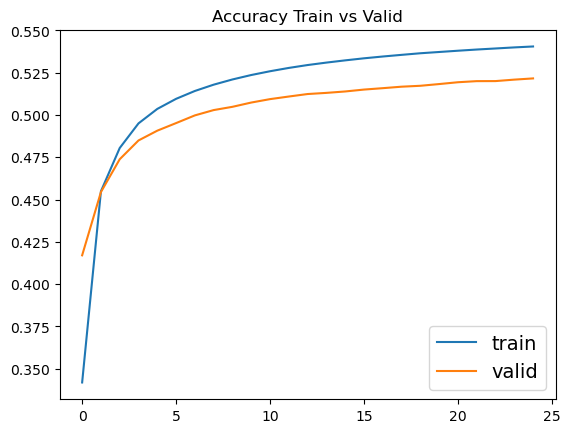

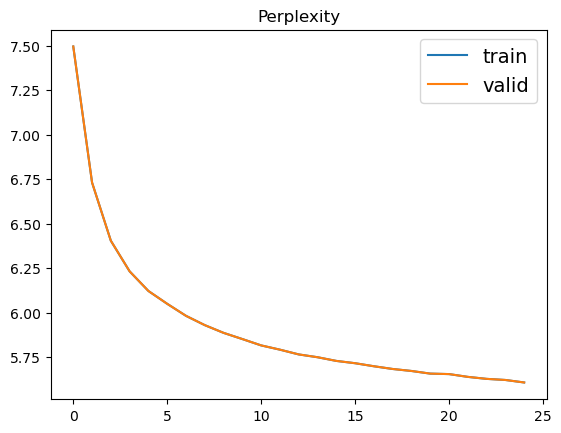

In [180]:
ploter(train_lstm_result['train_loss'], train_lstm_result['valid_loss'], "Loss Train vs Valid")
ploter(train_lstm_result['train_accuracy'], train_lstm_result['valid_accuracy'], "Accuracy Train vs Valid")
ploter(train_lstm_result['perplexity'], train_lstm_result['perplexity'], "Perplexity")

In [181]:
optimezer = torch.optim.RMSprop(params = gru_model.parameters(), lr = 0.0001)
gru_model_name = 'gru_model.pth'
train_gru_result = train(
    model = gru_model,
    train_loader = train_dataloader,
    valid_loader = val_dataloader,
    epochs = 25,
    loss_function = loss_function,
    optimizer = optimezer,
    model_name = gru_model_name
)

 Epoca: 0 | Train/Valid loss: 2.0445752371168076/1.9192913323102876) | Train/Valid acc: 0.386301189661026/0.44112542271614075) | Perpelexity: 6.816126823425293
Saved new model!
 Epoca: 1 | Train/Valid loss: 1.7059710774820518/1.8489526150172082) | Train/Valid acc: 0.4697268307209015/0.4661826193332672) | Perpelexity: 6.353161811828613
Saved new model!
 Epoca: 2 | Train/Valid loss: 1.641711847280176/1.8199787710117519) | Train/Valid acc: 0.4878028631210327/0.47964945435523987) | Perpelexity: 6.171727180480957
Saved new model!
 Epoca: 3 | Train/Valid loss: 1.607839326381269/1.805433075780903) | Train/Valid acc: 0.4972520172595978/0.4857470691204071) | Perpelexity: 6.082604885101318
Saved new model!
 Epoca: 4 | Train/Valid loss: 1.5861338287175495/1.796112979290431) | Train/Valid acc: 0.5032271146774292/0.48957517743110657) | Perpelexity: 6.026178359985352
Saved new model!
 Epoca: 5 | Train/Valid loss: 1.5707974243492433/1.7883219600584532) | Train/Valid acc: 0.5074014663696289/0.49275669

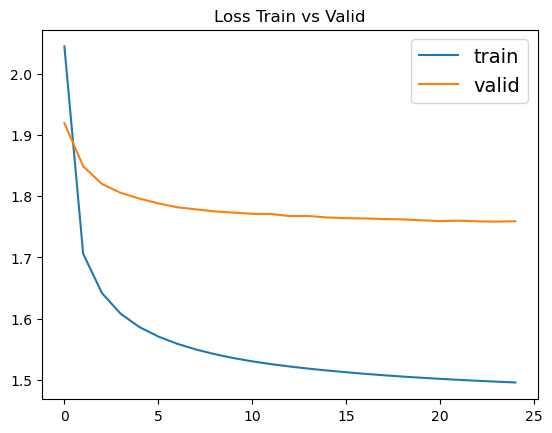

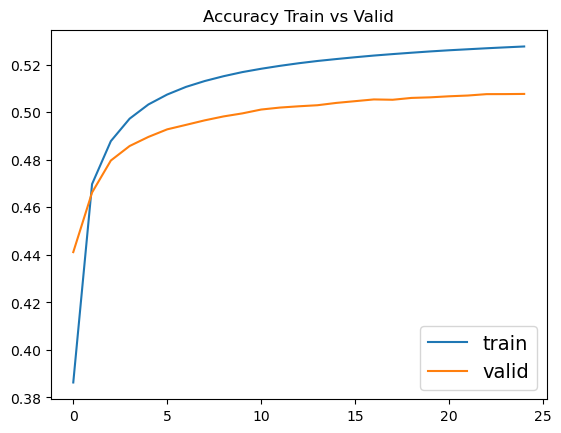

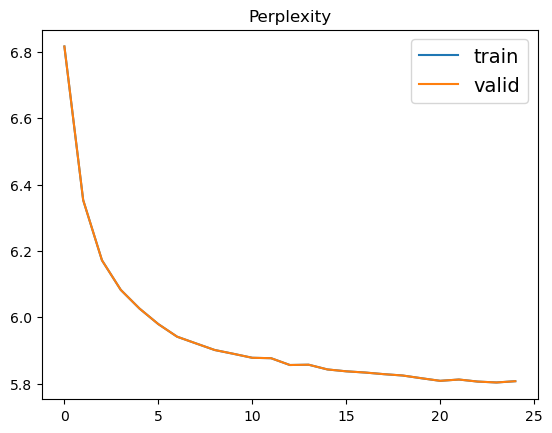

In [182]:
ploter(train_gru_result['train_loss'], train_gru_result['valid_loss'], "Loss Train vs Valid")
ploter(train_gru_result['train_accuracy'], train_gru_result['valid_accuracy'], "Accuracy Train vs Valid")
ploter(train_gru_result['perplexity'], train_gru_result['perplexity'], "Perplexity")

## Gready Search

In [183]:
def pad_sequence_pre(sequence, max_len, pad_value=0):
    """
    Pre-pad a sequence to max_len with pad_value.
    """
    # Ensure sequence is a list of integers
    if not isinstance(sequence, (list, tuple)):
        raise ValueError(f"Sequence must be a list or tuple, got {type(sequence)}")
    if not all(isinstance(x, int) for x in sequence):
        raise ValueError("Sequence must contain integers")
    
    # Convert to tensor
    tensor = torch.tensor(sequence, dtype=torch.long)
    pad_size = max_len - len(tensor)
    
    if pad_size > 0:
        padding = torch.full((pad_size,), pad_value, dtype=torch.long)
        tensor = torch.cat([padding, tensor])
    elif pad_size < 0:
        tensor = tensor[-max_len:]  # Truncate if too long
    return tensor

In [184]:
def gready_search(model, input_text, tokenizer, max_length, n_words):
    
    model.eval()
    output_text = input_text

    for _ in range(n_words):
        encoded = tokenizer.encode(output_text.lower())
        encoded = pad_sequence_pre(encoded, max_length)
        y_hat = model(encoded.unsqueeze(0).to(device))
        
        predict = np.argmax(y_hat[0, -1, :].cpu().detach().numpy()).item()

        out_word = ''
        out_word = tokenizer.decode([predict])[0]

        output_text += out_word

    return output_text


In [185]:
def select_candidates(preds, num_beams, vocab_size, history_probs, history_tokens, temp, mode):
    pred_large = []
    for idx, pp in enumerate(preds):
        pred_large.append(torch.log(pp + 1e-10) + history_probs[idx])
    pred_large = torch.cat(pred_large, dim=0).cpu().numpy()

    if mode == 'det':
        idx_select = np.argsort(pred_large)[::-1][:num_beams]
    elif mode == 'sto':
        probs = F.softmax(torch.tensor(pred_large) / temp, dim=0).numpy()
        idx_select = np.random.choice(np.arange(len(pred_large)), num_beams, p=probs)

    new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select // vocab_size],
                                         np.array([idx_select % vocab_size]).T), axis=1)
    return pred_large[idx_select], new_history_tokens

def beam_search(model, num_beams, num_words, input_text, tokenizer, max_context_size, temp=1.0, mode='det', device='cuda'):
    model.eval()
    encoded = tokenizer.encode(input_text.lower())
    
    padded = pad_sequence_pre(encoded, max_context_size - 1)
    
    input_tensor = padded.unsqueeze(0).to(device) 
    
    history_tokens = [padded.cpu().numpy()] * num_beams
    history_probs = [0.0] * num_beams

    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
        probs = F.softmax(logits, dim=-1)[0]

    history_probs, history_tokens = select_candidates([probs], num_beams, tokenizer.vocab_size,
                                                     history_probs, history_tokens, temp, mode)

    # Beam search loop
    for _ in range(num_words - 1):
        preds = []
        for hist in history_tokens:
            input_tensor = torch.tensor([hist[-(max_context_size - 1):]], dtype=torch.long).to(device)
            with torch.no_grad():
                logits = model(input_tensor)[:, -1, :]
                probs = F.softmax(logits, dim=-1)[0]
            preds.append(probs)
        history_probs, history_tokens = select_candidates(preds, num_beams, tokenizer.vocab_size,
                                                         history_probs, history_tokens, temp, mode)

    best_seq = history_tokens[0]
    decoded = tokenizer.decode(best_seq.tolist())
    return_text = "".join(decoded)

    return return_text

## Predicion con rrn

### Gready search

In [186]:
gready_search(rnn_model, "en un lugar de", tokenizer, 50, 20)

'en un lugar de la caballero de la '

### Beam search determinista y temp = 1

In [187]:
output = beam_search(
    model=rnn_model,
    num_beams=5,
    num_words=10,
    input_text="en un lugar ",
    tokenizer=tokenizer,
    max_context_size=max_context_size,
    temp=1.0,
    mode='det',
    device=device
)
print(output)
























































































en un lugar que no est


### Beam search estocatico y temp = 0.5

In [188]:
output = beam_search(
    model=rnn_model,
    num_beams=5,
    num_words=10,
    input_text="en un lugar de ",
    tokenizer=tokenizer,
    max_context_size=max_context_size,
    temp=0.5,
    mode='sto',
    device=device
)
print("Generated text:", output)

Generated text: 



















































































en un lugar de la merced 


### Beam search estocastico y temp = 10

In [189]:
output = beam_search(
    model=rnn_model,
    num_beams=5,
    num_words=10,
    input_text="en un lugar de ",
    tokenizer=tokenizer,
    max_context_size=max_context_size,
    temp=10,
    mode='sto',
    device=device
)
print("Generated text:", output)

Generated text: 



















































































en un lugar de jrcóétjgíj


## Prediccion LSTM

### Gready search

In [190]:
gready_search(lstm_model, "en un lugar de", tokenizer, 50, 20)


'en un lugar de la caballería de la'

### Beam search determinista y temp = 1

In [192]:
output = beam_search(
    model=lstm_model,
    num_beams=5,
    num_words=10,
    input_text="en un lugar de ",
    tokenizer=tokenizer,
    max_context_size=max_context_size,
    temp=1.0,
    mode='det',
    device=device
)
print("Generated text:", output)

Generated text: 



















































































en un lugar de la caballe


### Beam search estocastico y temp = 0.5

In [193]:
output = beam_search(
    model=lstm_model,
    num_beams=5,
    num_words=10,
    input_text="en un lugar de la ",
    tokenizer=tokenizer,
    max_context_size=max_context_size,
    temp=0.5,
    mode='sto',
    device=device
)
print("Generated text:", output)

Generated text: 
















































































en un lugar de la caballería


### Beam search estocastico y temp = 10

In [194]:
output = beam_search(
    model=lstm_model,
    num_beams=5,
    num_words=10,
    input_text="en un lugar de la ",
    tokenizer=tokenizer,
    max_context_size=max_context_size,
    temp=10,
    mode='sto',
    device=device
)
print("Generated text:", output)

Generated text: 
















































































en un lugar de la lrcaprí:xf


## Prediccion GRU

### Gready search

In [199]:
gready_search(gru_model, "en un lugar de", tokenizer, 50, 20)


'en un lugar de\r\nconsertado de la c'

### Beam search determinista y temp = 1

In [200]:
output = beam_search(
    model=gru_model,
    num_beams=5,
    num_words=10,
    input_text="en un lugar de la ",
    tokenizer=tokenizer,
    max_context_size=max_context_size,
    temp=1,
    mode='det',
    device=device
)
print("Generated text:", output)

Generated text: 
















































































en un lugar de la caballero


### Beam search estocastico y temp = 0.5

In [201]:
output = beam_search(
    model=gru_model,
    num_beams=5,
    num_words=10,
    input_text="en un lugar de la ",
    tokenizer=tokenizer,
    max_context_size=max_context_size,
    temp=0.5,
    mode='sto',
    device=device
)
print("Generated text:", output)

Generated text: 
















































































en un lugar de la cual
de l


### Beam search estocastico y temp = 10

In [202]:
output = beam_search(
    model=gru_model,
    num_beams=5,
    num_words=10,
    input_text="en un lugar de la ",
    tokenizer=tokenizer,
    max_context_size=max_context_size,
    temp=10,
    mode='sto',
    device=device
)
print("Generated text:", output)

Generated text: 
















































































en un lugar de la algüancjeí


# Conclusiones

Al comparar los resultados de entrenamiento y predicción de los tres modelos, podemos destacar lo siguiente:

* **RNN**: Tiende al sobreajuste (*overfitting*). Aunque converge rápidamente durante el entrenamiento, esta velocidad le impide generalizar correctamente y, por lo tanto, no logra obtener mejores resultados.

* **LSTM y GRU**: Muestran una convergencia gradual, reduciendo su perplejidad paso a paso. Sin embargo, su principal limitación es que no alcanzan una alta precisión (*accuracy*) ni una perplejidad cercana a uno.

* **Problemas en la Predicción**: Se detectaron problemas durante la generación de texto, principalmente al usar la búsqueda por haz (*beam search*), que tiende a producir secuencias con excesivos saltos de línea (`\n`). Esto podría deberse tanto al entrenamiento y la naturaleza de los datos como a la implementación del código.

* **Impacto de la Temperatura**: Se observa que la **temperatura** afecta drásticamente la calidad de las predicciones. Al variarla, el texto generado pasa de ser comprensible a convertirse en una secuencia de caracteres concatenados sin sentido ni palabras reconocibles.
